<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/01_EDA_Daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import anderson, kstest
from scipy.stats import t as student_t
from statsmodels.tsa.stattools import adfuller, kpss, acf
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

from google.colab import drive
from pathlib import Path
import json

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:

shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

df_raw = pd.read_parquet(
    shared_project_dir
    / "data"
    / "model_ready"
    / "crypto_daily_features_v1.parquet"
)

df_raw.head()

,open_time,close_time,asset,symbol,daily_open,daily_high,daily_low,daily_close,daily_volume,quote_volume,...,log_realized_variance,absolute_daily_return,high_low_range,log_volume,rv_mean_7d,rv_mean_30d,target_date,target_log_rv,target_rv,split
0,2017-08-17 00:00:00+00:00,2017-08-17 23:59:59.999000+00:00,BTC,BTCUSDT,4261.48,4485.39,4200.74,4285.08,795.150377,3.454770e+06,...,NaN,NaN,0.065565,6.679788,NaN,NaN,2017-08-18 00:00:00+00:00,-6.334804,0.001773,train
1,2017-08-18 00:00:00+00:00,2017-08-18 23:59:59.999000+00:00,BTC,BTCUSDT,4285.08,4371.52,3938.77,4108.37,1199.888264,5.086958e+06,...,-6.334804,0.042113,0.104242,7.090817,NaN,NaN,2017-08-19 00:00:00+00:00,-9.742286,0.000059,train
2,2017-08-19 00:00:00+00:00,2017-08-19 23:59:59.999000+00:00,BTC,BTCUSDT,4108.37,4184.69,3850.00,4139.98,381.309763,1.549484e+06,...,-9.742286,0.007665,0.083359,5.946231,NaN,NaN,2017-08-20 00:00:00+00:00,-8.677400,0.000170,train
3,2017-08-20 00:00:00+00:00,2017-08-20 23:59:59.999000+00:00,BTC,BTCUSDT,4120.98,4211.08,4032.62,4086.29,467.083022,1.930364e+06,...,-8.677400,0.013053,0.043303,6.148646,NaN,NaN,2017-08-21 00:00:00+00:00,-8.108200,0.000301,train
4,2017-08-21 00:00:00+00:00,2017-08-21 23:59:59.999000+00:00,BTC,BTCUSDT,4069.13,4119.62,3911.79,4016.00,691.743060,2.797232e+06,...,-8.108200,0.017351,0.051766,6.540659,NaN,NaN,2017-08-22 00:00:00+00:00,-10.245937,0.000036,train


In [3]:
df_pct_chg = df_raw.pivot(
    index="date",
    columns="asset",
    values="daily_return"
)

print(df_pct_chg.isna().sum())
df_pct_chg.tail()

asset
BTC       1
ETH       1
SOL    1091
XRP     261
dtype: int64


asset,BTC,ETH,SOL,XRP
date,,,,
2026-07-28 00:00:00+00:00,0.002493,0.015571,-0.004999,0.002717
2026-07-29 00:00:00+00:00,0.001083,-0.006006,-0.002034,0.004387
2026-07-30 00:00:00+00:00,0.012360,0.003964,0.011202,0.008532
2026-07-31 00:00:00+00:00,-0.029644,-0.029471,-0.022256,-0.019583
2026-08-01 00:00:00+00:00,-0.001022,-0.009527,-0.012706,-0.001414


In [4]:
ANNUALIZATION_FACTOR = 365

stats = []
for asset in df_pct_chg.columns:
    s = df_pct_chg[asset].dropna()
    if s.empty:
        continue

    stats.append({
        "asset": asset,
        "first_date": s.index.min(),
        "last_date": s.index.max(),
        "n_returns": s.count(),
        "annualized_mean_return": s.mean()*ANNUALIZATION_FACTOR,
        "annualized_std_return": s.std()*np.sqrt(ANNUALIZATION_FACTOR),
        "skewness": s.skew(),
        "kurtosis": s.kurt(),
        "min_return": s.min(),
        "max_return": s.max()
    })

stats_df = pd.DataFrame(stats).sort_values("first_date")

stats_df.T

,0,1,3,2
asset,BTC,ETH,XRP,SOL
first_date,2017-08-18 00:00:00+00:00,2017-08-18 00:00:00+00:00,2018-05-05 00:00:00+00:00,2020-08-12 00:00:00+00:00
last_date,2026-08-01 00:00:00+00:00,2026-08-01 00:00:00+00:00,2026-08-01 00:00:00+00:00,2026-08-01 00:00:00+00:00
n_returns,3271,3271,3011,2181
annualized_mean_return,0.299632,0.201947,0.021249,0.515871
annualized_std_return,0.679009,0.877458,0.980262,1.147398
skewness,-0.958498,-0.887287,0.583981,-0.208894
kurtosis,15.84281,11.996536,18.849113,8.259309
min_return,-0.502607,-0.590534,-0.538657,-0.549008
max_return,0.202952,0.23375,0.548698,0.377554


In [5]:
summary_rows = []
trimmed_rows = []

for asset in df_pct_chg.columns:
    s = df_pct_chg[asset].dropna()
    if s.empty:
        continue

    mean_val = s.mean()
    std_val = s.std()
    lower = mean_val - 1.96 * std_val
    upper = mean_val + 1.96 * std_val

    within_ci = s[(s >= lower) & (s <= upper)].copy()
    dropped = s.size - within_ci.size

    summary_rows.append({
        "asset": asset,
        "n_values_considered": within_ci.size,
        "n_values_dropped": dropped,
        "annualized_mean": within_ci.mean()*ANNUALIZATION_FACTOR,
        "annualized_std": within_ci.std()*np.sqrt(ANNUALIZATION_FACTOR),
        "skewness": within_ci.skew(),
        "kurtosis": within_ci.kurt(),
        "min": within_ci.min(),
        "max": within_ci.max(),
    })

    for value in within_ci:
        trimmed_rows.append({
            "asset": asset,
            "trimmed_value": value,
        })

summary_df = pd.DataFrame(summary_rows)
trimmed_values_df = pd.DataFrame(trimmed_rows)

summary_df.T

,0,1,2,3
asset,BTC,ETH,SOL,XRP
n_values_considered,3072,3090,2065,2870
n_values_dropped,199,181,116,141
annualized_mean,0.21801,0.354584,0.029647,-0.385182
annualized_std,0.465808,0.630321,0.829988,0.633519
skewness,-0.066457,0.002201,0.119668,-0.031205
kurtosis,0.424757,0.247233,0.019492,0.565677
min,-0.068553,-0.089366,-0.116218,-0.099948
max,0.070434,0.089953,0.119104,0.10048


In [6]:
returns_df = df_pct_chg.copy().dropna(how='all')
squared_returns_df = returns_df.pow(2)

returns_df.head()
squared_returns_df.head()

asset,BTC,ETH,SOL,XRP
date,,,,
2017-08-18 00:00:00+00:00,0.001773,0.000728,NaN,NaN
2017-08-19 00:00:00+00:00,0.000059,0.000109,NaN,NaN
2017-08-20 00:00:00+00:00,0.000170,0.000771,NaN,NaN
2017-08-21 00:00:00+00:00,0.000301,0.006048,NaN,NaN
2017-08-22 00:00:00+00:00,0.000036,0.001817,NaN,NaN


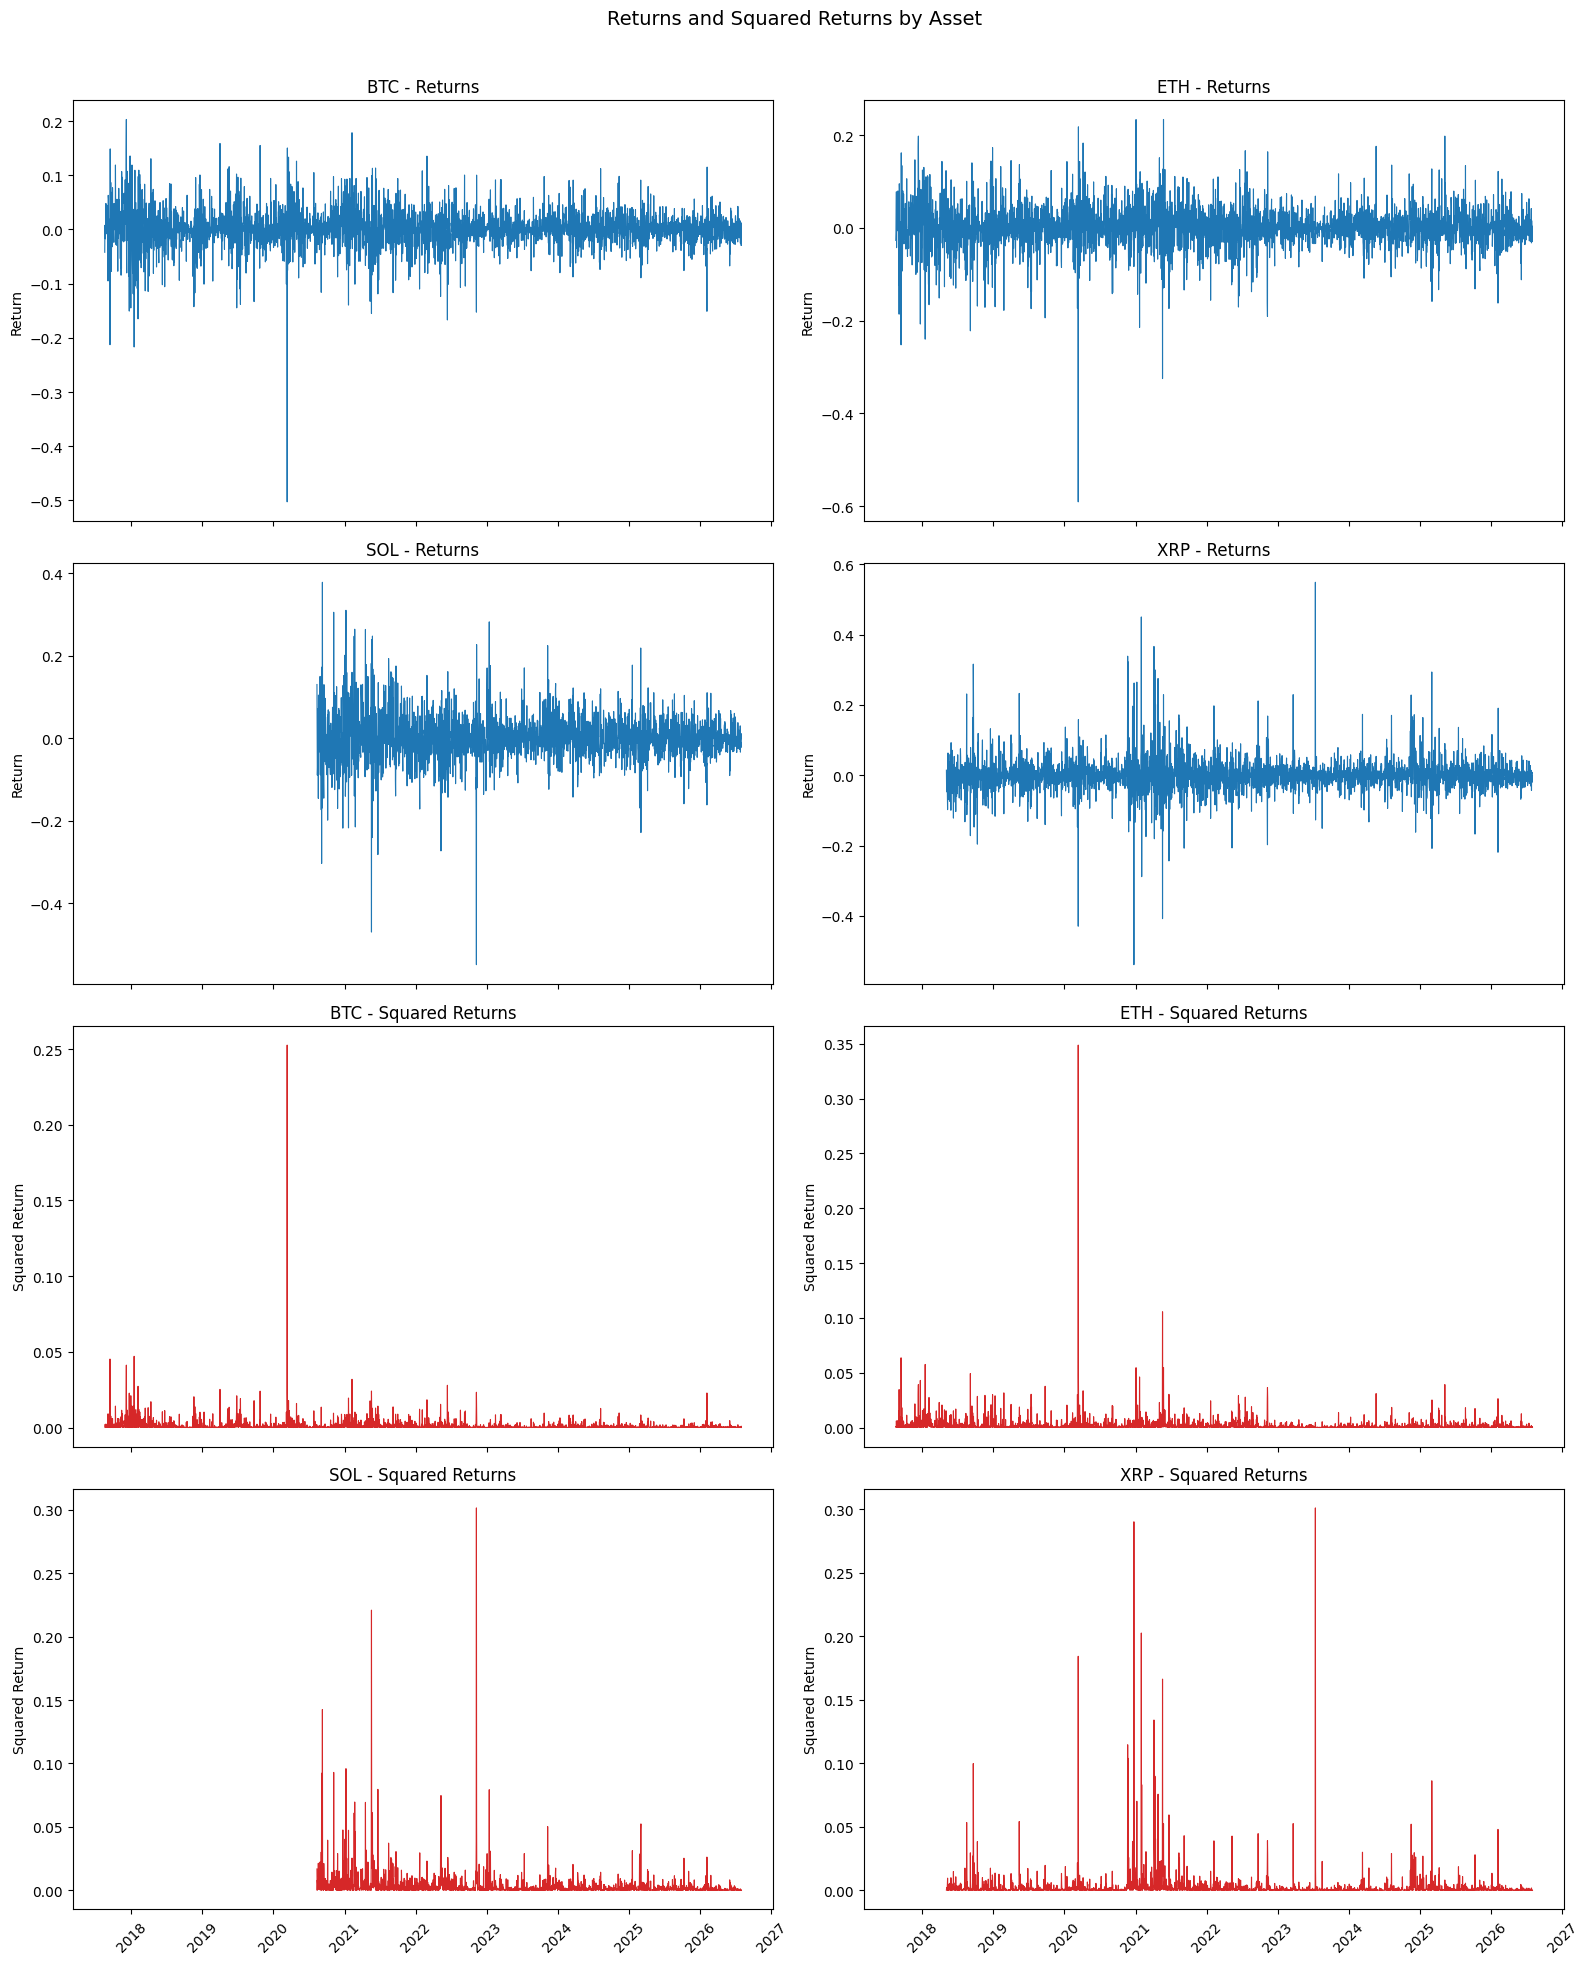

In [7]:
assets = list(returns_df.columns)
assets_to_plot = assets[:8]

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes = axes.flatten()

for ax, asset in zip(axes, assets_to_plot):
    ax.plot(returns_df.index, returns_df[asset], color='tab:blue', linewidth=0.8)
    ax.set_title(f'{asset} - Returns')
    ax.set_ylabel('Return')
    ax.tick_params(axis='x', rotation=45)

for ax, asset in zip(axes[len(assets_to_plot):], assets_to_plot):
    ax.plot(squared_returns_df.index, squared_returns_df[asset], color='tab:red', linewidth=0.8)
    ax.set_title(f'{asset} - Squared Returns')
    ax.set_ylabel('Squared Return')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(assets_to_plot)*2:]:
    ax.axis('off')

fig.suptitle('Returns and Squared Returns by Asset', fontsize=14)
plt.subplots_adjust(wspace=0.25, hspace=0.45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [8]:
rows = []
for asset in df_pct_chg.columns:
    s = df_pct_chg[asset].dropna()
    if s.empty:
        continue

    for test_name, regression, label in [
        ("ADF", "c", "without trend"),
        ("ADF", "ct", "with trend"),
        ("KPSS", "c", "without trend"),
        ("KPSS", "ct", "with trend"),
    ]:
        if test_name == "ADF":
            result = adfuller(s, autolag="AIC", regression=regression)
            statistic = result[0]
            pvalue = result[1]
            used_lag = result[2]
            # nobs = result[3]
            # critical_values = result[4]
        else:
            result = kpss(s, regression=regression, nlags="auto")
            statistic = result[0]
            pvalue = result[1]
            used_lag = result[2]
            # nobs = result[3]
            # critical_values = result[4]

        rows.append({
            "asset": asset,
            "test": test_name,
            "specification": label,
            "statistic": statistic,
            "pvalue": pvalue,
            "used_lag": used_lag,
            # "nobs": nobs,
            # "critical_values": critical_values,
            # "reject_5pct": pvalue < 0.05,
        })

unit_root_results_df = pd.DataFrame(rows)
print(unit_root_results_df)

/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression=regression, nlags="auto")
/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression=regression, nlags="auto")
/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression=regression, nlags="auto")
/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = k

   asset  test  specification  statistic        pvalue  used_lag
0    BTC   ADF  without trend -39.737627  0.000000e+00         1
1    BTC   ADF     with trend -39.741454  0.000000e+00         1
2    BTC  KPSS  without trend   0.094418  1.000000e-01        10
3    BTC  KPSS     with trend   0.059634  1.000000e-01        10
4    ETH   ADF  without trend -39.758979  0.000000e+00         1
5    ETH   ADF     with trend -39.757144  0.000000e+00         1
6    ETH  KPSS  without trend   0.105458  1.000000e-01        13
7    ETH  KPSS     with trend   0.086504  1.000000e-01        13
8    SOL   ADF  without trend -13.442763  3.816537e-25         9
9    SOL   ADF     with trend -48.955229  0.000000e+00         0
10   SOL  KPSS  without trend   0.334164  1.000000e-01         4
11   SOL  KPSS     with trend   0.121309  9.572339e-02         4
12   XRP   ADF  without trend -57.318846  0.000000e+00         0
13   XRP   ADF     with trend -57.316315  0.000000e+00         0
14   XRP  KPSS  without t

/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression=regression, nlags="auto")
/tmp/ipykernel_1171/2678788107.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(s, regression=regression, nlags="auto")


In [9]:
dist_names = ["norm", "expon", "logistic", "gumbel_l", "gumbel_r"]

results = []
for asset in df_pct_chg.columns:
    pct = df_pct_chg[asset].dropna()
    if pct.empty:
        continue

    for dist in dist_names:
        stat, critical_values, significance_levels = anderson(pct, dist=dist)
        results.append({
            "asset": asset,
            "distribution": dist,
            "method": "anderson",
            "statistic": stat,
            "critical_values": critical_values,
            "significance_levels": significance_levels,
            "reject_5pct": stat > critical_values[list(significance_levels).index(5)],
        })

    params = student_t.fit(pct)
    ks_stat, ks_pvalue = kstest(pct, "t", args=params)
    results.append({
        "asset": asset,
        "distribution": "student_t",
        "method": "kstest",
        "statistic": ks_stat,
        "params": params,
        "reject_5pct": ks_pvalue < 0.05,
        "pvalue": ks_pvalue,
    })

results_df = pd.DataFrame(results)
print(results_df[["asset", "distribution", "method", "statistic", "reject_5pct", "pvalue"]])

   asset distribution    method    statistic  reject_5pct    pvalue
0    BTC         norm  anderson    67.974237         True       NaN
1    BTC        expon  anderson          inf         True       NaN
2    BTC     logistic  anderson    19.382504         True       NaN
3    BTC     gumbel_l  anderson   195.383699         True       NaN
4    BTC     gumbel_r  anderson   530.782852         True       NaN
5    BTC    student_t    kstest     0.020364        False  0.130859
6    ETH         norm  anderson    52.107403         True       NaN
7    ETH        expon  anderson          inf         True       NaN
8    ETH     logistic  anderson    12.896698         True       NaN
9    ETH     gumbel_l  anderson   161.843554         True       NaN
10   ETH     gumbel_r  anderson   466.453273         True       NaN
11   ETH    student_t    kstest     0.018433        False  0.213681
12   SOL         norm  anderson    28.400867         True       NaN
13   SOL        expon  anderson          inf    

In [10]:
lags = [10, 15, 20]
rows = []

for asset in df_pct_chg.columns:
    s = squared_returns_df[asset].dropna()
    if s.empty:
        continue

    for lag in lags:
        lb = acorr_ljungbox(s, lags=[lag], return_df=True)
        row = lb.loc[lag]
        rows.append({
            "asset": asset,
            "lag": lag,
            "lb_statistic": row["lb_stat"],
            "lb_pvalue": row["lb_pvalue"],
            "reject_5pct": row["lb_pvalue"] < 0.05,
        })

ljung_box_results_df = pd.DataFrame(rows)
print(ljung_box_results_df)

   asset  lag  lb_statistic     lb_pvalue  reject_5pct
0    BTC   10     93.569113  1.046735e-15         True
1    BTC   15    115.336306  1.513194e-17         True
2    BTC   20    128.994745  6.016089e-18         True
3    ETH   10    133.533354  8.872224e-24         True
4    ETH   15    142.601265  7.052889e-23         True
5    ETH   20    151.829495  2.803992e-22         True
6    SOL   10    323.354267  1.777081e-63         True
7    SOL   15    347.434747  7.224601e-65         True
8    SOL   20    356.872056  1.706632e-63         True
9    XRP   10    158.667487  6.103574e-29         True
10   XRP   15    177.302649  8.311955e-30         True
11   XRP   20    185.008368  1.012838e-28         True


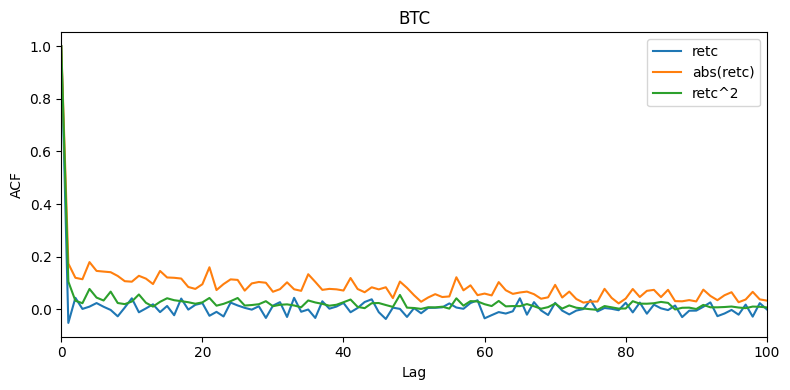

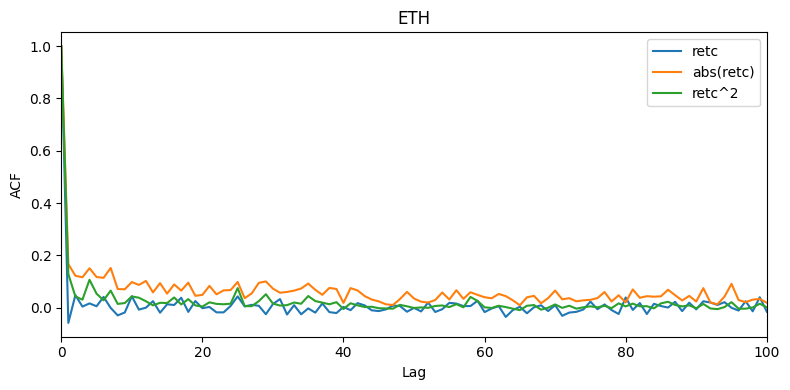

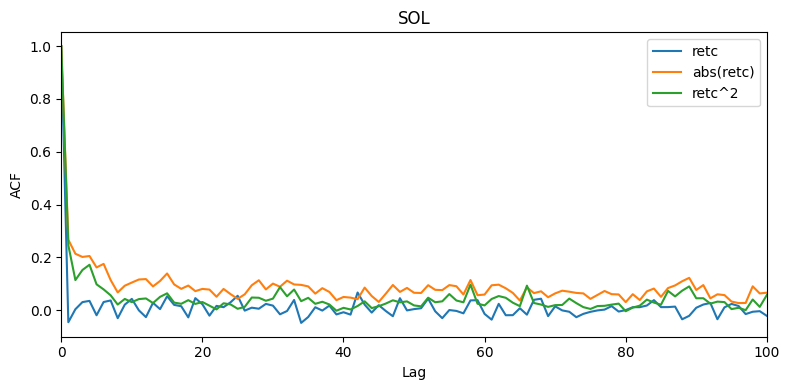

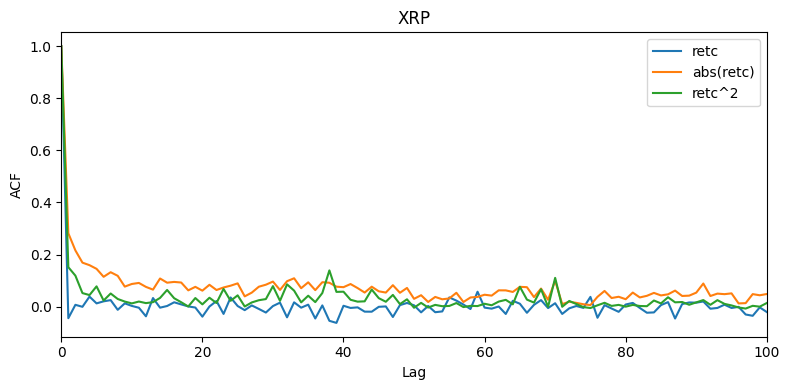

In [11]:
max_lag = 100

for asset in returns_df.columns:
    s = returns_df[asset].dropna()
    if s.empty:
        continue

    s_abs = s.abs()
    s_sq = s.pow(2)
    n = s.size

    acf_ret = acf(s, nlags=max_lag, fft=True)
    acf_abs = acf(s_abs, nlags=max_lag, fft=True)
    acf_sq = acf(s_sq, nlags=max_lag, fft=True)

    ci = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(8, 4))
    l1, = ax.plot(acf_ret, label='retc', color='tab:blue')
    l2, = ax.plot(acf_abs, label='abs(retc)', color='tab:orange')
    l3, = ax.plot(acf_sq, label='retc^2', color='tab:green')

    # ax.axhline(ci, color='purple', linestyle='--', linewidth=0.9, label='cip')
    # ax.axhline(-ci, color='red', linestyle='--', linewidth=0.9, label='cin')

    ax.set_xlim(0, max_lag)
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.set_title(f'{asset}')
    ax.legend(loc='upper right')
    plt.tight_layout()

    # show and save
    plt.show()
    # try:
    #     fig.savefig(f"acf_{asset}.png", dpi=150, bbox_inches='tight')
    # except Exception:
    #     pass
    # plt.close(fig)

In [12]:
# # Faster unit-root test run: test a subset of the data first and keep the same output structure.
# # You can increase the sample size later if needed.

# sample_size = 10000
# assets_to_test = list(df_pct_chg.columns)

# rows = []
# for asset in assets_to_test:
#     s = df_pct_chg[asset].dropna()
#     if s.empty:
#         continue

#     # Use the most recent observations to reduce runtime.
#     s = s.tail(sample_size)

#     for test_name, regression, label in [
#         ("ADF", "c", "without trend"),
#         ("ADF", "ct", "with trend"),
#     ]:
#         result = adfuller(s, autolag="AIC", regression=regression)
#         rows.append({
#             "asset": asset,
#             "test": test_name,
#             "specification": label,
#             "statistic": result[0],
#             "pvalue": result[1],
#             "used_lag": result[2],
#             "nobs": result[3],
#             "critical_values": result[4],
#             "reject_5pct": result[1] < 0.05,
#         })

# unit_root_results_df = pd.DataFrame(rows)
# print(unit_root_results_df)